<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02e%20algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

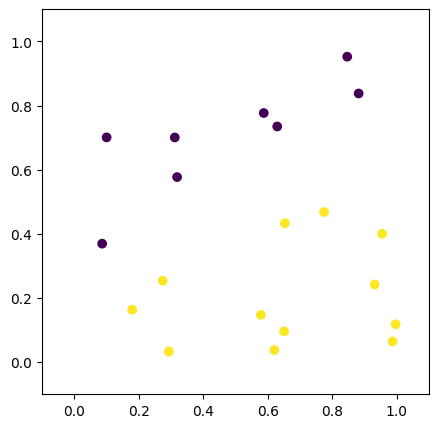

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, coef=0.5, intercept=0.2):
  X = np.random.rand(n,2)
  y = np.array(X[:,0]*coef>(X[:,1]-intercept), dtype=int)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

plotDataset(X, y)
plt.show()

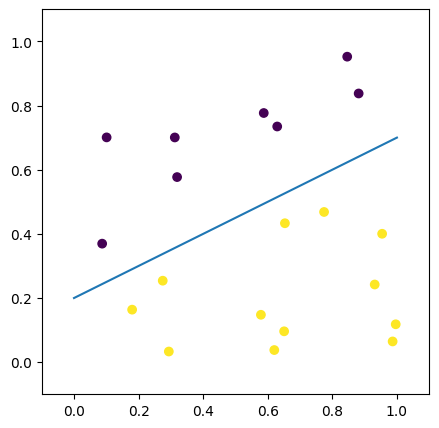

In [34]:
def plotHyperplan(vector, intercept=0):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

plotDataset(X, y)
plotHyperplan(np.array([0.5,-1]), 0.2)
plt.show()


In [23]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

In [29]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class PseudoInverse(TrainingAlgorithm):
  def getW(self, X, y):
    w = np.linalg.pinv(X) @ y
    return w

Accuracy: 1.0
Weights: [ 0.79399837  0.9513875  -2.83296492]


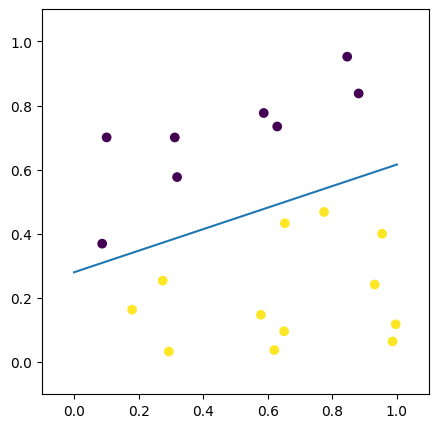

In [46]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm=PseudoInverse()):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = self.trainingAlgorithm.getW(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    return np.sign(X @ self.w_)

pinv = NeuralNetwork()
pinv.fit(X, y)
ypred = pinv.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {pinv.w_}")
plotDataset(X, y)
plotHyperplan(pinv.w_[1:], pinv.w_[0])
plt.show()

In [37]:
class PLA(TrainingAlgorithm):
  def __init__(self, max_iter=100):
    self.max_iter = max_iter
  def getW(self, X, y):
    w = np.random.uniform(size=X.shape[1])*2-1
    for _ in range(self.max_iter):
      cost = 0
      idx = np.arange(X.shape[0])
      np.random.shuffle(idx)
      for i in idx:
        ypred = sign(X[i] @ w)
        error = y[i] - ypred
        if error != 0:
          cost += error**2
          w += error * X[i]
      if cost == 0:
        break
    return w

Accuracy: 1.0
Weights: [ 0.89581809  1.50450958 -3.06044355]


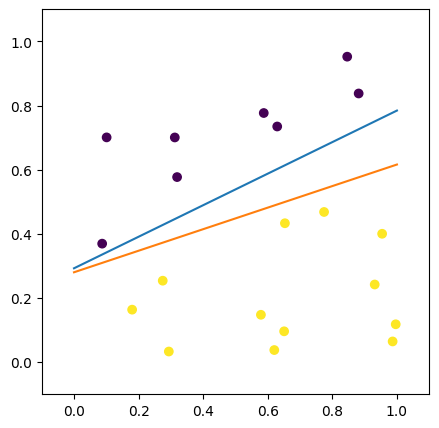

In [61]:
pla = NeuralNetwork(trainingAlgorithm=PLA())
pla.fit(X, y)
ypred = pla.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {pla.w_}")
plotDataset(X, y)
plotHyperplan(pla.w_[1:], pla.w_[0])
plotHyperplan(pinv.w_[1:], pinv.w_[0])
plt.show()